<a href="https://colab.research.google.com/github/cnpdomo-stack/TELECOM-X-LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:
import pandas as pd


url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)
df.head()



,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [ ]:
account_df = pd.json_normalize(df['account'])
customer_df = pd.json_normalize(df['customer'])
internet_df = pd.json_normalize(df['internet'])
phone_df = pd.json_normalize(df['phone'])

df_expanded = pd.concat([df.drop(columns=['account', 'customer','internet', 'phone']), account_df, customer_df, internet_df, phone_df], axis=1)

print(df_expanded.select_dtypes(include=['int64', 'float64']).columns)


Index(['Charges.Monthly', 'SeniorCitizen', 'tenure'], dtype='object')


In [ ]:
df_expanded.head()

,customerID,Churn,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines
0,0002-ORFBO,No,One year,Yes,Mailed check,65.6,593.3,Female,0,Yes,Yes,9,DSL,No,Yes,No,Yes,Yes,No,Yes,No
1,0003-MKNFE,No,Month-to-month,No,Mailed check,59.9,542.4,Male,0,No,No,9,DSL,No,No,No,No,No,Yes,Yes,Yes
2,0004-TLHLJ,Yes,Month-to-month,Yes,Electronic check,73.9,280.85,Male,0,No,No,4,Fiber optic,No,No,Yes,No,No,No,Yes,No
3,0011-IGKFF,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Male,1,Yes,No,13,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,No
4,0013-EXCHZ,Yes,Month-to-month,Yes,Mailed check,83.9,267.4,Female,1,Yes,No,3,Fiber optic,No,No,No,Yes,Yes,No,Yes,No


In [ ]:
df_expanded['Cuentas_Diarias'] = df_expanded['Charges.Monthly'] / 30.5
df_expanded.head()


,customerID,Churn,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Cuentas_Diarias
0,0002-ORFBO,No,One year,Yes,Mailed check,65.6,593.3,Female,0,Yes,Yes,9,DSL,No,Yes,No,Yes,Yes,No,Yes,No,2.150820
1,0003-MKNFE,No,Month-to-month,No,Mailed check,59.9,542.4,Male,0,No,No,9,DSL,No,No,No,No,No,Yes,Yes,Yes,1.963934
2,0004-TLHLJ,Yes,Month-to-month,Yes,Electronic check,73.9,280.85,Male,0,No,No,4,Fiber optic,No,No,Yes,No,No,No,Yes,No,2.422951
3,0011-IGKFF,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Male,1,Yes,No,13,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,No,3.213115
4,0013-EXCHZ,Yes,Month-to-month,Yes,Mailed check,83.9,267.4,Female,1,Yes,No,3,Fiber optic,No,No,No,Yes,Yes,No,Yes,No,2.750820


#📊 Carga y análisis

In [ ]:
df_expanded.describe()

,Charges.Monthly,SeniorCitizen,tenure,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,64.720098,0.162653,32.346498,2.121970
std,30.129572,0.369074,24.571773,0.987855
min,18.250000,0.000000,0.000000,0.598361
25%,35.425000,0.000000,9.000000,1.161475
50%,70.300000,0.000000,29.000000,2.304918
75%,89.875000,0.000000,55.000000,2.946721
max,118.750000,1.000000,72.000000,3.893443


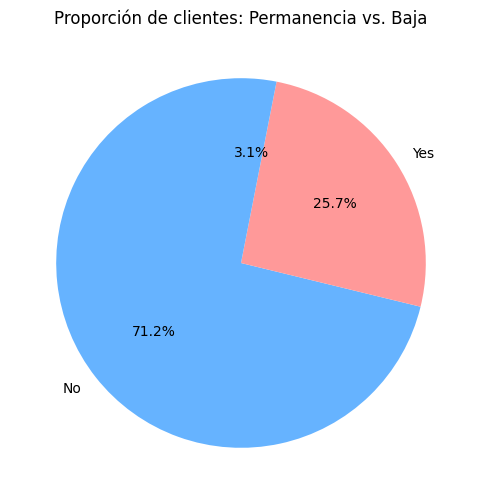

In [ ]:
import matplotlib.pyplot as plt
churn_counts = df_expanded['Churn'].value_counts()

plt.figure(figsize=(6, 6))
churn_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Proporción de clientes: Permanencia vs. Baja')
plt.ylabel('')
plt.show()

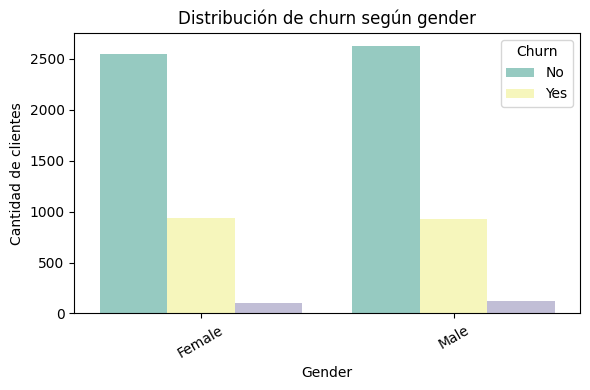

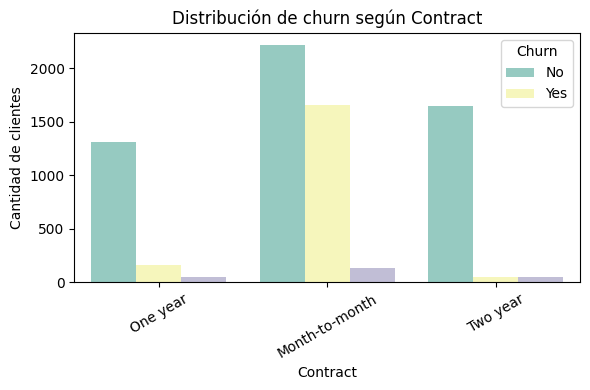

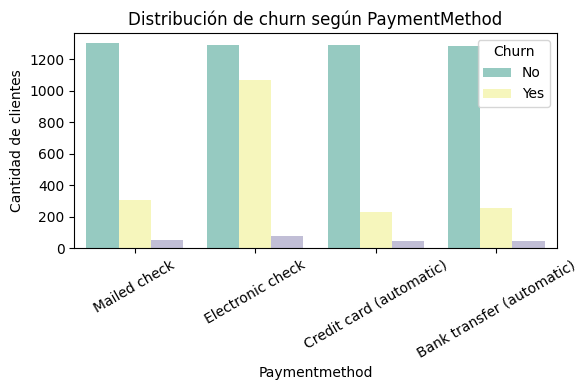

In [98]:
import seaborn as sns
categorical_vars = ['gender', 'Contract', 'PaymentMethod']

for var in categorical_vars:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_expanded, x=var, hue='Churn', palette='Set3')
    plt.title(f'Distribución de churn según {var}')
    plt.xlabel(var.capitalize())
    plt.ylabel('Cantidad de clientes')
    plt.legend(title='Churn')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-3816084253.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_expanded, x='Churn', y=var, palette='Set3')


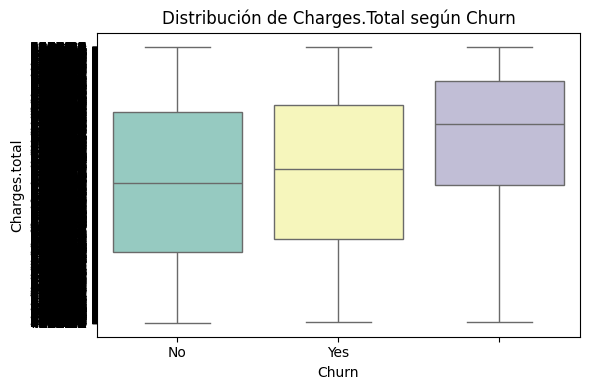

/tmp/ipython-input-3816084253.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_expanded, x='Churn', y=var, palette='Set3')


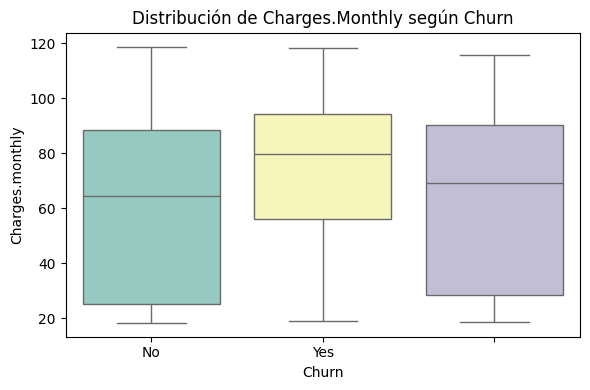

/tmp/ipython-input-3816084253.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_expanded, x='Churn', y=var, palette='Set3')


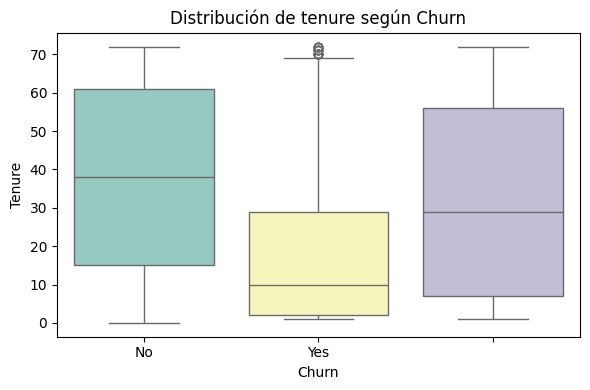

In [97]:
numeric_vars = ['Charges.Total', 'Charges.Monthly', 'tenure']

for var in numeric_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df_expanded, x='Churn', y=var, palette='Set3')
    plt.title(f'Distribución de {var} según Churn')
    plt.xlabel('Churn')
    plt.ylabel(var.replace('_', ' ').capitalize())
    plt.tight_layout()
    plt.show()

#📄Informe final

**Análisis de la Retención y Baja de Clientes en TELECOM X**

En el presente informe se analiza la proporción de clientes que mantienen sus servicios activos frente a aquellos que han decidido cancelar su suscripción en la empresa TELECOM X. La tasa de retención de clientes se estima en aproximadamente un 71%, mientras que el 25.7% de los usuarios ha solicitado la baja de sus servicios. Es importante mencionar que los datos cuentan con un margen de error del 3%.

De acuerdo con los gráficos incluidos en este análisis, no se observa una relación estadísticamente significativa entre el género de los clientes y su permanencia en la compañía. Sin embargo, el método de contratación se identifica como un factor determinante, ya que se registra una mayor tasa de abandono en los planes mensuales en comparación con la estabilidad que presentan los contratos a uno o dos años.

Adicionalmente, el análisis del método de pago, presentado en el gráfico número 2, muestra una diferencia considerable en la permanencia o abandono de los clientes. En particular, el pago mediante cheque electrónico está asociado con una mayor incidencia de bajas en comparación con los cobros automáticos realizados con tarjetas de crédito.

Finalmente, el gráfico tipo Boxplot evidencia que la cantidad de cargos efectuados es otro factor relevante a considerar, dado que un mayor número de cargos se relaciona con una mayor propensión al abandono. Asimismo, se observa que la cancelación tiende a ocurrir principalmente en los primeros meses tras la contratación, mientras que la permanencia se incrementa conforme aumenta el tiempo de vínculo con la empresa.